<a href="https://colab.research.google.com/github/kotatech24/AIML/blob/main/day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, datasets, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalization
X_train = X_train/255
Y_train = Y_train/255

In [4]:
#flattening the images
X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1, 784)

In [5]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
# encoding
encoder = tf.keras.Sequential([
    layers.Dense(128, activation = 'relu'),
    layers.Dense(32, activation = 'relu')
])

In [7]:
# decoding
decoder = tf.keras.Sequential([
    layers.Dense(128, activation = 'relu'),
    layers.Dense(784, activation='sigmoid') # 28 by 28 because we want final answer as reconstructed like original image
])

In [8]:
autoencoder = tf.keras.Sequential([
    encoder,
    decoder
])

In [9]:
# compile the autoencoder
autoencoder.compile ( optimizer = 'adam', loss = 'binary_crossentropy')

In [12]:
autoencoder.fit(X_train,X_train, epochs = 5, batch_size = 6, validation_data=(X_test, X_test))

Epoch 1/5
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - loss: 0.0854 - val_loss: -39824.1133
Epoch 2/5
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - loss: 0.0848 - val_loss: -39948.0508
Epoch 3/5
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - loss: 0.0843 - val_loss: -41040.7500
Epoch 4/5
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - loss: 0.0839 - val_loss: -40191.0195
Epoch 5/5
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 76s 5ms/step - loss: 0.0836 - val_loss: -41053.9961


In [11]:
reconstructed = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


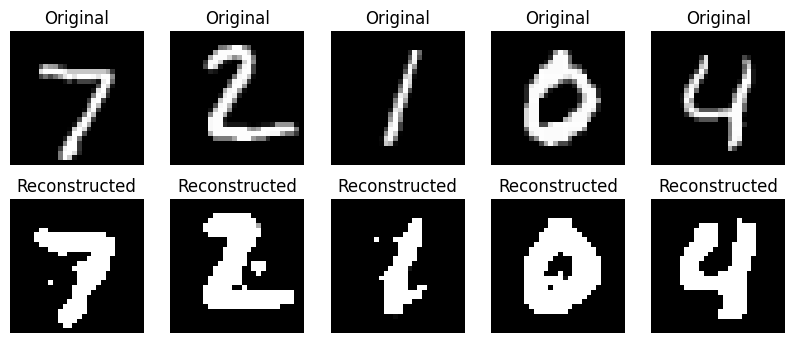

In [13]:
# check how original image is different from predicted

n = 5
plt.figure(figsize=(10,4))
for i in range(n):
  ax = plt.subplot(2, n, i+1)
  plt.imshow(X_test[i].reshape(28,28), cmap = 'grey')
  plt.title("Original")
  plt.axis("off")


  ax = plt.subplot(2, n, i+1+n)
  plt.imshow(reconstructed[i].reshape(28,28), cmap = 'grey')
  plt.title("Reconstructed")
  plt.axis("off")

plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import BernoulliRBM

In [20]:
# this is a data of customer preference
# rows => customers
# columns => products

data = np.array([
    [1,1,0,0],
    [1,1,0,1],
    [0,0,1,1],
    [1,0,1,1],
    [0,1,1,0]
])

In [21]:
# create model for RBM

rbm = BernoulliRBM(
    n_components=2,
    learning_rate=0.1,
    n_iter=100
)

In [22]:
rbm.fit(data)

BernoulliRBM(n_components=2, n_iter=100)

In [23]:
BernoulliRBM(n_components=2, n_iter=100)
In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

BernoulliRBM
?Documentation for BernoulliRBMiFitted
BernoulliRBM(n_components=2, n_iter=100)

SyntaxError: invalid syntax (1158917481.py, line 2)

In [24]:
# transform data into hidden features
hidden = rbm.transform(data)
print("hidden features\n", hidden)

hidden features
 [[0.0602003  0.05986449]
 [0.04395138 0.04367157]
 [0.06064671 0.05956099]
 [0.04383324 0.04311852]
 [0.06405826 0.06236539]]


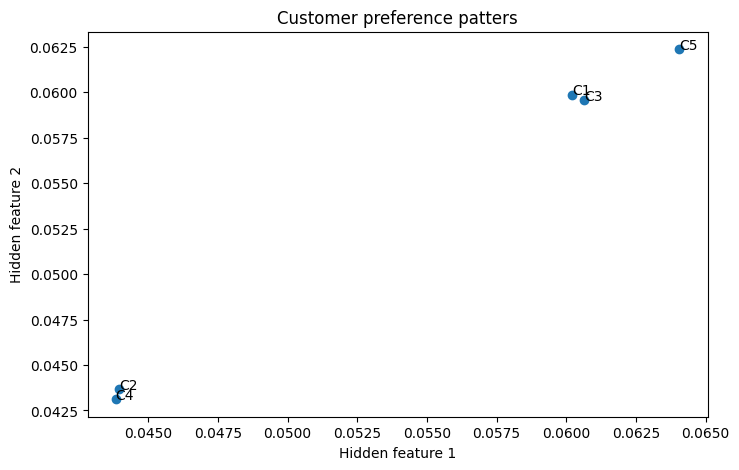

In [25]:
# plot hidden representations
plt.figure(figsize=(8,5))
plt.scatter(hidden[:,0], hidden[:,1])
for i in range(len(hidden)):
  plt.text(hidden[i,0], hidden[i,1], f"C{i+1}")
plt.xlabel("Hidden feature 1")
plt.ylabel("Hidden feature 2")
plt.title("Customer preference patters")
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import BernoulliRBM

In [27]:
digits = load_digits()
x = digits.data
y = digits.target

In [28]:
y

array([0, 1, 2, ..., 8, 9, 8])

In [29]:
print(x.shape) # we have 8 X 8 pixel images

(1797, 64)


In [30]:
# normalise
scaler = MinMaxScaler()
X = scaler.fit_transform(x)

In [31]:
rbm = BernoulliRBM(
    n_components=100,
    learning_rate=0.01,
    batch_size = 20,
    n_iter=20,
    random_state = 20
)

In [32]:
rbm.fit(X)

BernoulliRBM(batch_size=20, learning_rate=0.01, n_components=100, n_iter=20,
             random_state=20)